# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **UCI Wine Dataset** dari UCI Machine Learning Repository. Dataset ini berisi hasil analisis kimia terhadap tiga jenis wine yang berasal dari kultivar berbeda di wilayah Italia yang sama. Tujuan pemodelan adalah melakukan klasifikasi `wine_class` berdasarkan 13 fitur numerik hasil pengukuran kimia.

Sumber dataset: https://archive.ics.uci.edu/dataset/109/wine

# **2. Import Library**

Pada tahap ini, library yang dibutuhkan untuk eksplorasi data, visualisasi, dan preprocessing akan diimpor terlebih dahulu.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# **3. Memuat Dataset**

Dataset mentah dimuat dari folder `wine_raw` untuk memastikan proses experimentation menggunakan data raw sebelum dilakukan preprocessing.

In [2]:
raw_path = Path("../wine_raw/wine.csv")
data = pd.read_csv(raw_path)

display(data.head())
print(f"Jumlah baris: {data.shape[0]}")
print(f"Jumlah kolom: {data.shape[1]}")
data.info()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Jumlah baris: 178
Jumlah kolom: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280_od315_of_diluted_wines  178 non-null    float64
 12  proline                      

# **4. Exploratory Data Analysis (EDA)**

Tahap EDA dilakukan untuk memahami struktur data, distribusi target, nilai hilang, duplikasi data, statistik deskriptif, dan hubungan antarfitur sebelum dataset diproses lebih lanjut.

Jumlah missing value per kolom:


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280_od315_of_diluted_wines    0
proline                         0
wine_class                      0
dtype: int64

Jumlah duplikasi data: 0
Distribusi target wine_class:


wine_class
0    59
1    71
2    48
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03000,12.3625,13.050,13.6775,14.83000
malic_acid,178.0,2.330435,1.100173,0.74000,1.6025,1.865,3.0825,5.30250
ash,178.0,2.366721,0.263705,1.68875,2.2100,2.360,2.5575,3.07875
alcalinity_of_ash,178.0,19.478090,3.287757,10.75000,17.2000,19.500,21.5000,27.95000
magnesium,178.0,99.483146,13.414186,70.00000,88.0000,98.000,107.0000,135.50000
total_phenols,178.0,2.295112,0.625851,0.98000,1.7425,2.355,2.8000,3.88000
flavanoids,178.0,2.029270,0.998859,0.34000,1.2050,2.135,2.8750,5.08000
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13000,0.2700,0.340,0.4375,0.66000
proanthocyanins,178.0,1.586067,0.558153,0.41000,1.2500,1.555,1.9500,3.00000
color_intensity,178.0,5.038146,2.260881,1.28000,3.2200,4.690,6.2000,10.67000


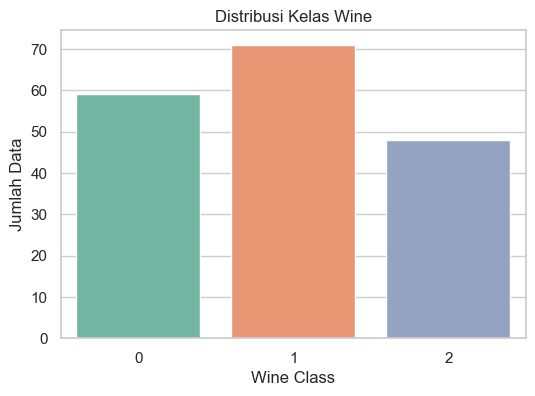

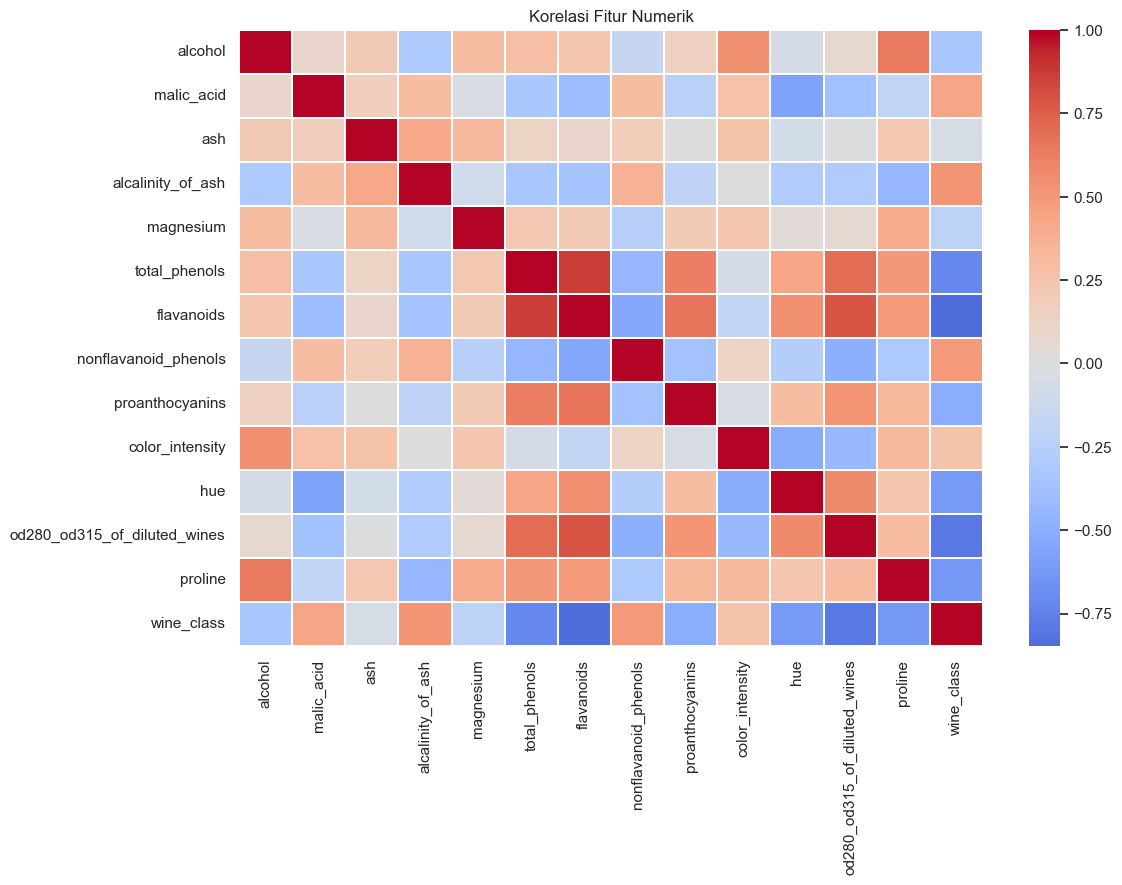

In [3]:
print("Jumlah missing value per kolom:")
display(data.isna().sum())

print(f"Jumlah duplikasi data: {data.duplicated().sum()}")

print("Distribusi target wine_class:")
display(data["wine_class"].value_counts().sort_index())

display(data.describe().T)

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="wine_class", hue="wine_class", palette="Set2", legend=False)
plt.title("Distribusi Kelas Wine")
plt.xlabel("Wine Class")
plt.ylabel("Jumlah Data")
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Korelasi Fitur Numerik")
plt.show()

# **5. Data Preprocessing**

Tahap preprocessing dilakukan dengan memisahkan kolom target, menangani missing value menggunakan median untuk fitur numerik, melakukan standardisasi fitur numerik menggunakan `StandardScaler`, lalu menyimpan dataset yang sudah siap dilatih ke folder `wine_preprocessing`.

In [4]:
target_column = "wine_class"
processed_data = data.copy()
numeric_columns = [column for column in processed_data.columns if column != target_column]

missing_before = processed_data.isna().sum().to_dict()
for column in numeric_columns:
    processed_data[column] = processed_data[column].fillna(processed_data[column].median())

if processed_data[target_column].isna().any():
    processed_data[target_column] = processed_data[target_column].fillna(processed_data[target_column].mode()[0])

scaler = StandardScaler()
processed_data[numeric_columns] = scaler.fit_transform(processed_data[numeric_columns])
processed_data[target_column] = processed_data[target_column].astype(int)

output_dir = Path("wine_preprocessing")
output_dir.mkdir(parents=True, exist_ok=True)
processed_data.to_csv(output_dir / "processed_wine.csv", index=False)

summary = {
    "dataset": "UCI Wine Dataset",
    "source": "https://archive.ics.uci.edu/dataset/109/wine",
    "rows": int(processed_data.shape[0]),
    "columns": int(processed_data.shape[1]),
    "target_column": target_column,
    "target_distribution": processed_data[target_column].value_counts().sort_index().astype(int).to_dict(),
    "numeric_columns": numeric_columns,
    "missing_before": {key: int(value) for key, value in missing_before.items()},
    "missing_after": {key: int(value) for key, value in processed_data.isna().sum().to_dict().items()},
}

with (output_dir / "preprocessing_summary.json").open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

display(processed_data.head())
print(f"Dataset preprocessing tersimpan di: {output_dir / 'processed_wine.csv'}")

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,wine_class
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009,0
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242,0
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148,0
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574,0
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874,0


Dataset preprocessing tersimpan di: wine_preprocessing\processed_wine.csv
